# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Victor Tavares Estrada"            # Tu nombre completo
MATRICULA = "80988"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "homicidios"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Victor Tavares Estrada
Matrícula: 80988
Dataset asignado: homicidios


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\tvic1\Documents\Universidad La Salle Bajio\ISSC\5to Semestre\Topicos_de_Big_Data\Practicas_BigData\U1_2_Examen\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: homicidios
Descripcion: Numero de homicidios intencionales por anio (homicidios)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,2009,1115.000,Asia
1,Afghanistan,AFG,2010,983.000,Asia
2,Afghanistan,AFG,2011,1231.000,Asia
3,Afghanistan,AFG,2012,1948.000,Asia
4,Afghanistan,AFG,2015,3367.000,Asia
5,Afghanistan,AFG,2016,2318.000,Asia
6,Afghanistan,AFG,2017,2424.000,Asia
7,Afghanistan,AFG,2018,2474.000,Asia
8,Afghanistan,AFG,2019,2712.000,Asia
9,Afghanistan,AFG,2020,2570.000,Asia


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(4914, 5)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4914 entries, 0 to 4913
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   entity       4914 non-null   str    
 1   code         4399 non-null   str    
 2   year         4914 non-null   int64  
 3   valor        4914 non-null   float64
 4   owid_region  4220 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 192.1 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count      4914.000000
mean       8582.853861
std       37590.820449
min           0.000000
25%          37.000000
50%         256.500000
75%        1171.968475
max      450728.880000
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           515
year             0
valor            0
owid_region    694
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Se presentan cero nulos en las columnas más críticas (year y valor), concentrando estos huecos en "code" y "owid region" porque incluye agrupaciones continentales. El rango temporal en años abarca aproximadamente desde el 2000 hasta el 2021. Nuestra variable continua a trabajar en este notebook, "valor" (float64), muestra un fuerte sesgo a la derecha, con un promedio de 8,582 homicidios anuales y un máximo superior a 450,000

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [15]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df[config['filtro_paises']].notnull()] #eliminación de nulos

num_paises = df_paises['entity'].nunique()
print(f"Cantidad de países distintos: {num_paises}\n")

top_mayor = (
    df_paises.groupby("entity")["valor"]
    .max()
    .sort_values(ascending=False)
)
top_menor = (
    df_paises.groupby("entity")["valor"]
    .min()
    .sort_values(ascending=True)
)

print("10 países con MAYOR valor")
print(top_mayor.head(10))

print("\n10 países con MENOR valor")
print(top_menor.head(10))


Cantidad de países distintos: 200

10 países con MAYOR valor
entity
Brazil           63788.0
Nigeria          63400.0
India            49688.0
Russia           47870.0
Mexico           36773.0
Colombia         28441.0
China            27356.0
South Africa     27272.0
United States    24703.0
Venezuela        19030.0
Name: valor, dtype: float64

10 países con MENOR valor
entity
American Samoa            0.0
Andorra                   0.0
Anguilla                  0.0
Aruba                     0.0
Bahrain                   0.0
Bermuda                   0.0
British Virgin Islands    0.0
Cayman Islands            0.0
Liechtenstein             0.0
Luxembourg                0.0
Name: valor, dtype: float64


**Interpretación:**

*El dataset contiene 200 países reales distintos. Al analizar los rankings, observamos que los países con **mayor** tasa de homicidios son **Brasil, Nigeria e India**, lo que podemos atribuira su volumen poblacional. Por otro lado, el ranking de **menor** valor está compuesto por entidades muy pequeñas como **American Samoa o Andorra**, donde se pueden llegar a registrar incluso 0 homicidios en un año.*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [ ]:
# Pregunta 2
# Tu codigo aqui
pais1 = "Mexico"
pais2 = "Brazil"

df_pais1 = df_paises[df_paises["entity"] == pais1] #rango de años de cada país
df_pais2 = df_paises[df_paises["entity"] == pais2]

anios_pais1 = df_pais1["year"].to_numpy()
anios_pais2 = df_pais2["year"].to_numpy()
anios_en_comun = np.intersect1d(anios_pais1, anios_pais2) #años en común

condicion_paises = df_paises["entity"].isin([pais1, pais2])
condicion_anios = df_paises["year"].isin(anios_en_comun)

df_mex_bra = df_paises[condicion_paises & condicion_anios]
df_mex_bra = df_mex_bra.sort_values(by=["year", "entity"])

print(f"Años en común entre {pais1} y {pais2}: {anios_en_comun.min()} a {anios_en_comun.max()}\n")
print(df_mex_bra.head(10))


Años en común entre Mexico y Brazil: 1990 a 2023

      entity code  year      valor    owid_region
689   Brazil  BRA  1990  29301.190  South America
2718  Mexico  MEX  1990  14493.000  North America
690   Brazil  BRA  1991  28148.473  South America
2719  Mexico  MEX  1991  15128.000  North America
691   Brazil  BRA  1992  25966.840  South America
2720  Mexico  MEX  1992  16594.000  North America
692   Brazil  BRA  1993  28012.752  South America
2721  Mexico  MEX  1993  16040.000  North America
693   Brazil  BRA  1994  29851.412  South America
2722  Mexico  MEX  1994  15839.000  North America


**Interpretación:**

*Para asegurar una comparación justa y sin sesgos entre México y Brasil, filtramos el dataset para obtener únicamente los años que ambos comparten. El resultado indica un periodo continuo que va desde 1990 hasta 2023. Esto nos permite contrastar a estos dos paíese en igualdad de condiciones y evita sacar conclusiones erróneas.*

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [21]:
# Pregunta 3
# Tu codigo aqui
paises = ["Mexico", "Japan", "Nigeria", "Germany", "Australia"]
df_5 = df_paises[df_paises["entity"].isin(paises)]

df_reciente = df_5.sort_values("year", ascending=False).drop_duplicates(subset="entity") #año más reciente por país

print("Datos del año más reciente disponible para los 5 países:")
print(df_reciente[["entity", "year", "valor"]].to_string(index=False))

idx_max = df_reciente["valor"].idxmax() #pais con valor mayor y menor
idx_min = df_reciente["valor"].idxmin()

pais_max = df_reciente.loc[idx_max]
pais_min = df_reciente.loc[idx_min]

diferencia = pais_max["valor"] - pais_min["valor"]

print(f"\nValor más ALTO: {pais_max['entity']}, {pais_max['valor']} homicidios (Año {pais_max['year']})")
print(f"Valor más BAJO: {pais_min['entity']}, {pais_min['valor']} homicidios (Año {pais_min['year']})")
print(f"Diferencia: {diferencia} homicidios")


Datos del año más reciente disponible para los 5 países:
   entity  year   valor
  Nigeria  2023 35884.0
  Germany  2023   770.0
Australia  2023   226.0
    Japan  2023   285.0
   Mexico  2023 32252.0

Valor más ALTO: Nigeria, 35884.0 homicidios (Año 2023)
Valor más BAJO: Australia, 226.0 homicidios (Año 2023)
Diferencia: 35658.0 homicidios


**Interpretación:**

*Tomando 5 países pertenecientes a distintos continentes, se extrajo el registro más reciente de cada uno. El país con la cifra más alta fue **Nigeria** con **35,884** homicidios, mientras que **Australia** apenas reporta **226**. La diferencia absoluta entre ambos paíes es de **35,658** homicidios.*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [22]:
# Pregunta 4
# Tu codigo aqui
latam = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

df_grupos = df_paises[df_paises["entity"].isin(latam + asia)]
df_reciente = df_grupos.sort_values("year", ascending=False).drop_duplicates(subset="entity").copy()

mapeo_grupos = {
    "Mexico": "Latinoamérica", "Colombia": "Latinoamérica", "Argentina": "Latinoamérica",
    "China": "Asia", "Japan": "Asia", "Vietnam": "Asia"
}
df_reciente["Grupo"] = df_reciente["entity"].map(mapeo_grupos)

print("Datos más recientes de cada país")
print(df_reciente[["Grupo", "entity", "year", "valor"]].sort_values("Grupo").to_string(index=False))

promedios_grupo = (
    df_reciente.groupby("Grupo")["valor"]
    .mean()
    .sort_values(ascending=False)
)

print("\nPromedio de Homicidios de cada grupo")
print(promedios_grupo)

Datos más recientes de cada país
        Grupo    entity  year   valor
         Asia     Japan  2023   285.0
         Asia     China  2020  7157.0
         Asia   Vietnam  2011  1358.0
Latinoamérica Argentina  2023  2046.0
Latinoamérica  Colombia  2023 13035.0
Latinoamérica    Mexico  2023 32252.0

Promedio de Homicidios de cada grupo
Grupo
Latinoamérica    15777.666667
Asia              2933.333333
Name: valor, dtype: float64


**Interpretación:**

*Latinoamérica presenta una media de **15,777.67** homicidios, superando drásticamente al grupo de Asia, cuyo promedio se sitúa en apenas **2,933.33**. Esta gran diferencia está impulsada fuertemente por las cifras de México (32,252 casos en 2023) y Colombia (13,035). Japón registra únicamente 285 incidentes en el mismo año.*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [26]:
# Pregunta 5
# Tu codigo aqui
pais_elegido = "Colombia"
df_pais = df_paises[df_paises["entity"] == pais_elegido].sort_values("year")

idx_max = df_pais["valor"].idxmax()
idx_min = df_pais["valor"].idxmin()

anio_max = df_pais.loc[idx_max, "year"]
valor_max = df_pais.loc[idx_max, "valor"]
anio_min = df_pais.loc[idx_min, "year"]
valor_min = df_pais.loc[idx_min, "valor"]

print(f"Análisis temporal de {pais_elegido}:")
print(f"El valor MÍNIMO fue de {valor_min} homicidios en {anio_min}")
print(f"El valor MÁXIMO fue de {valor_max} homicidios en {anio_max}\n")

print("Evolución inicial vs actual")
print(pd.concat([df_pais[["year", "valor"]].head(3), df_pais[["year", "valor"]].tail(3)]).to_string(index=False))


Análisis temporal de Colombia:
El valor MÍNIMO fue de 11464.0 homicidios en 2020
El valor MÁXIMO fue de 28441.0 homicidios en 1993

Evolución inicial vs actual
 year   valor
 1990 24330.0
 1991 28424.0
 1992 28184.0
 2021 13094.0
 2022 12908.0
 2023 13035.0


**Interpretación:**

*Analizando la evolución histórica de Colombia, el valor máximo se alcanzó en **1993** con **28,441** homicidios, mientras que el punto mínimo se data de **2020** con **11,464** casos. La tendencia general es claramente decreciente, reduciéndose a más de la mitad, demostrando los avances en seguridad del país.*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [27]:
# Pregunta 6
# Tu codigo aqui
df_mexico = df_paises[df_paises["entity"] == "Mexico"].sort_values("year")

primer_anio = df_mexico.iloc[0]
ultimo_anio = df_mexico.iloc[-1]

cambio_pct = ((ultimo_anio["valor"] - primer_anio["valor"]) / primer_anio["valor"]) * 100

print(f"Año inicial ({primer_anio['year']}): {primer_anio['valor']}")
print(f"Año final ({ultimo_anio['year']}): {ultimo_anio['valor']}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")

Año inicial (1990): 14493.0
Año final (2023): 32252.0
Cambio porcentual: 122.54%


**Interpretación:**

*Al analizar a México entre **1990 y 2023**, la cifra anual pasó de **14,493** a **32,252**, lo que representa un drástico incremento relativo del **122.54%**. Esta fuerte tendencia en aumento refleja el severo deterioro de la seguridad nacional y el aumento del crimen organizado.*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [28]:
# Pregunta 7
# Tu codigo aqui
df_reciente = df_paises.sort_values('year', ascending=False).drop_duplicates(subset='entity')
valores = df_reciente['valor'].dropna().to_numpy()

media = np.mean(valores)
mediana = np.median(valores)
desv_std = np.std(valores)

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desv_std:.2f}")


Media: 1762.80
Mediana: 101.00
Desviación Estándar: 5887.16


**Interpretación:**

*Para el año más reciente disponible a nivel global, se calculó una media de 1,762.80 homicidios, una mediana de apenas 101 y una  desviación estándar de 5,887.16. La enorme diferencia entre la media y la mediana evidencia un sesgo en la distribución: la mayoría de los países presenta cifras bajas, mientras que unos pocos con valores extremos distorsionan el promedio hacia arriba.*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

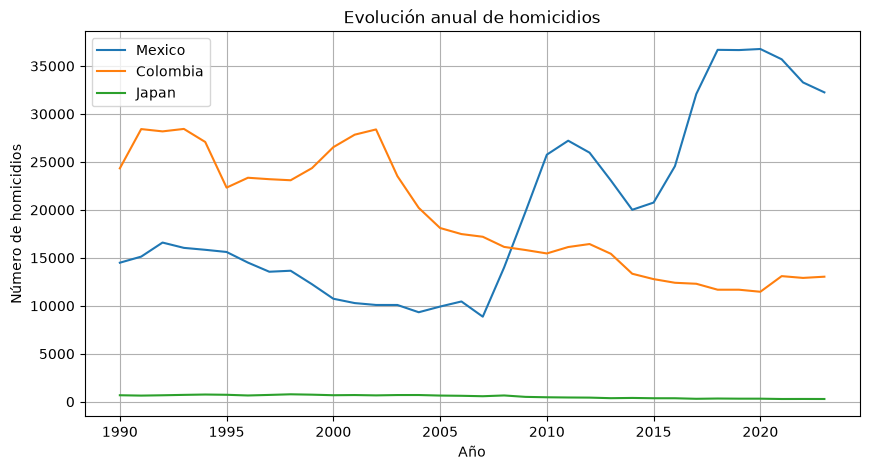

In [29]:
# Pregunta 8
# Tu codigo aqui
paises_plot = ["Mexico", "Colombia", "Japan"]
df_plot = df_paises[df_paises["entity"].isin(paises_plot)]

plt.figure(figsize=(10, 5))

for pais in paises_plot:
    df_temp = df_plot[df_plot["entity"] == pais].sort_values("year")
    plt.plot(df_temp["year"], df_temp["valor"], label=pais)

plt.title("Evolución anual de homicidios")
plt.xlabel("Año")
plt.ylabel("Número de homicidios")
plt.grid(True)
plt.legend()
plt.show()

**Interpretación:**

*Colombia muestra una clara tendencia a la baja desde los **años 90**, mientras que México sufre un aumento drástico a partir de **2007**, superando las cifra de Colombia. Japón se mantiene casi en cero, reflejando realidades de seguridad opuestas.*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

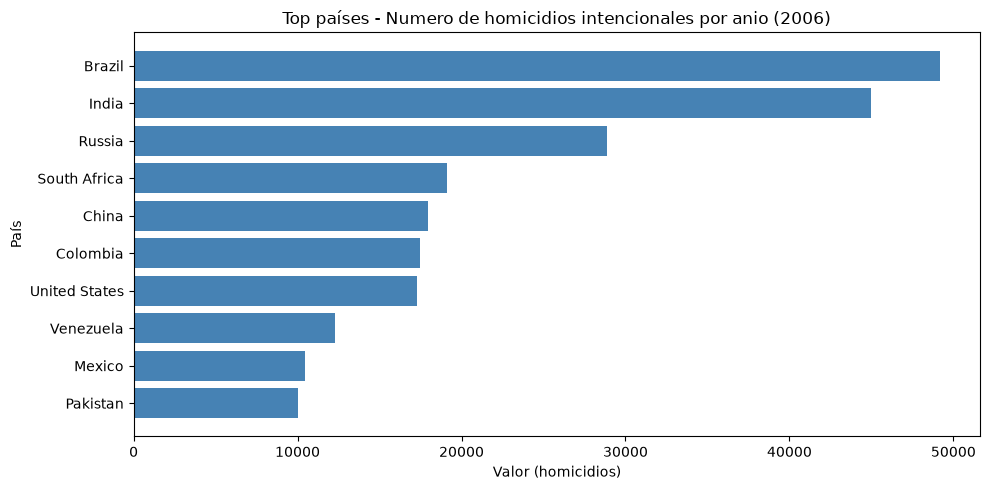

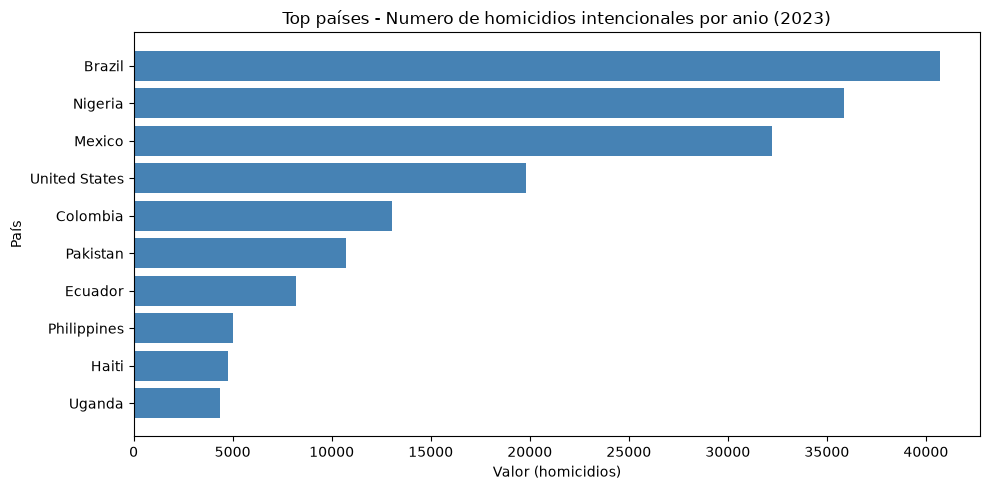

In [32]:
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2006
anio_actual = 2023

top_nac = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_nac['entity'], top_nac['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_nacimiento})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_act = (
    df_paises[df_paises['year'] == anio_actual]
    .sort_values('valor', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_act['entity'], top_act['valor'], color='steelblue')
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_actual})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación:**

*Al comparar los años **2006** y **2023**, se vuelve muy notorio el ascenso de México, que pasó del noveno al tercer lugar, y la salida de países como **India** y **Rusia**. Por otro lado, Brasil se mantiene como líder en ambas fechas gracias a ser una potencia demográfica, aunque México destaca por su gran incremento dada la situación creciente de insegutridad y crimen organizado en gobiernos recientes.*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*El análisis de este dataset revela que, al mostrar los valores absolutos de cada país, el ranking global está dominado por naciones altamente pobladas, lo que encubre la verdadera intensidad de la violencia. Sin embargo es posible encontrar patrones claros y muy reveladores, como el alza constante de la violencia en Colombia desde los 90's y el repunte en México a partir de 2007. Y por supuesto, dado el gigante geográfico que es Brasil en el continente americano, este lidera de forma perpetua los tops. Una limitante importante y algo incómoda fue la inconsistencia en los años de reporte, por lo que fué necesario igualar periodos o buscar años recientes mediante código. Con el tiempo suficiente, sería prudente calcular una tasa "per capita", lo que permitiría desarrollar una comparación mucho más justa y detallada.*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
